<a href="https://colab.research.google.com/github/rijal0708/data-science-2026/blob/main/Pertemuan13_M_Rijal_Anshory_DJ_240401010281.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama    = M Rijal Anshory DJ.

NIM     = 240401010281

Kelas   = IF403

---



1. generate & eksplorasi dataset non linear

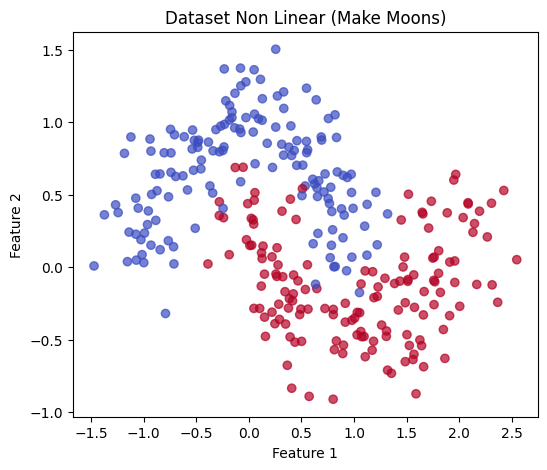

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

plt.figure(figsize=(6,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.title("Dataset Non Linear (Make Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

2. bangun neural network

In [4]:
from re import VERBOSE
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = Sequential([
    Dense(
        16,
        activation='relu',
        input_shape=(2,)
    ),
    Dense(
        8,
        activation='relu'
    ),
    Dense(
        1,
        activation='sigmoid'
    )

])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
history = model.fit(
    X_tr, y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5104 - loss: 0.7091 - val_accuracy: 0.6042 - val_loss: 0.6810
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5573 - loss: 0.6919 - val_accuracy: 0.6458 - val_loss: 0.6663
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5990 - loss: 0.6773 - val_accuracy: 0.6667 - val_loss: 0.6524
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6719 - loss: 0.6641 - val_accuracy: 0.7708 - val_loss: 0.6394
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7083 - loss: 0.6508 - val_accuracy: 0.7917 - val_loss: 0.6273
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7240 - loss: 0.6390 - val_accuracy: 0.8333 - val_loss: 0.6159
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7760 - loss: 0.6280 - val_accuracy: 0.8542 - val_loss: 0.6050
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8073 - loss: 0.6172 - val_accuracy: 0.8333 - val_loss: 0.5940


3. evaluasi

Akurasi Data Uji : 0.900


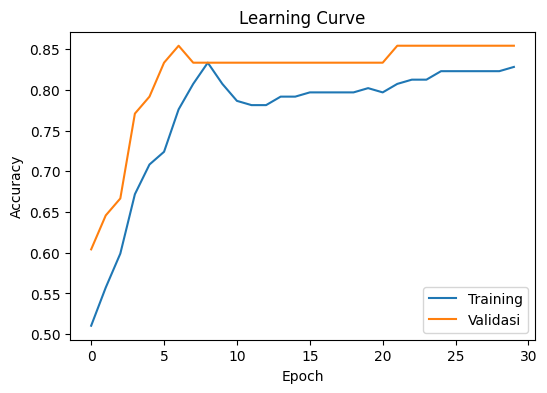

In [6]:
loss, acc = model.evaluate(
    X_te, y_te,
    verbose=0
)

print(f"Akurasi Data Uji : {acc:.3f}")

plt.figure(figsize=(6,4))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validasi"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.title("Learning Curve")

plt.show()

Jika grafik training dan validation saling berdekatan:


>   Model belajar dengan baik dan tidak menunjukkan indikasi overfitting.


Jika training jauh lebih tinggi:



> Terjadi overfitting karena model terlalu menghafal data training.

---





4. dataset sentimen (40 ulasan)

In [7]:
ulasan = [

"Barangnya bagus banget, pengiriman cepat",
"Kualitas jelek, tidak sesuai deskripsi",
"Sangat puas, akan beli lagi",
"Kecewa, barang rusak saat sampai",
"Recommended, harga sesuai kualitas",
"Buruk sekali, tidak sesuai ekspektasi",
"Pelayanan ramah dan cepat",
"Produk sangat memuaskan",
"Sangat berkualitas",
"Harga murah kualitas bagus",
"Packing rapi dan aman",
"Respon penjual cepat",
"Barang original",
"Saya puas dengan produk ini",
"Pengiriman sangat cepat",
"Produk sesuai foto",
"Terima kasih sangat memuaskan",
"Kualitas premium",
"Layak dibeli",
"Sangat direkomendasikan",

"Barang rusak",
"Tidak puas",
"Pengiriman sangat lama",
"Produk palsu",
"Kecewa sekali",
"Jelek kualitasnya",
"Tidak akan beli lagi",
"Packing buruk",
"Respon penjual lambat",
"Sangat mengecewakan",
"Harga mahal kualitas jelek",
"Produk cacat",
"Tidak sesuai gambar",
"Barang tidak berfungsi",
"Pelayanan buruk",
"Sangat buruk",
"Kurang memuaskan",
"Tidak recommended",
"Kecewa berat",
"Produk tidak layak"

]

label = [

1,0,1,0,1,0,
1,1,1,1,1,
1,1,1,1,
1,1,1,1,1,

0,0,0,0,0,
0,0,0,0,0,
0,0,0,0,0,
0,0,0,0,0

]

5. TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print(
    "Jumlah kata unik:",
    len(tfidf.get_feature_names_out())
)

print(
    tfidf.get_feature_names_out()[:20]
)

Jumlah kata unik: 59
['akan' 'aman' 'bagus' 'banget' 'barang' 'barangnya' 'beli' 'berat'
 'berfungsi' 'berkualitas' 'buruk' 'cacat' 'cepat' 'dan' 'dengan'
 'deskripsi' 'dibeli' 'direkomendasikan' 'ekspektasi' 'foto']


6. logistic regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label,
    test_size=0.2,
    random_state=42
)

model_sentimen = LogisticRegression()
model_sentimen.fit(
    Xt_tr,
    yt_tr
)

akurasi = model_sentimen.score(
    Xt_tr,
    yt_tr
)

print(f"Akurasi : {akurasi:.3f}")

kalimat_baru = [
    "Pelayanan sangat memuaskan dan ramah"
]

pred = model_sentimen.predict(
    tfidf.transform(kalimat_baru)
)

print(
    "Prediksi:",
    "Positif" if pred[0]==1 else "Negatif"
)

Akurasi : 0.875
Prediksi: Negatif


7. kesimpulan

Neural Network

> Neural Network berhasil mempelajari pola non-linear pada dataset make_moons dengan baik. Akurasi data uji yang tinggi menunjukkan bahwa penggunaan fungsi aktivasi ReLU dan Sigmoid efektif untuk memisahkan dua kelas yang tidak dapat dipisahkan secara linear. Kurva pembelajaran juga menunjukkan bahwa akurasi training dan validasi relatif berdekatan sehingga model tidak mengalami overfitting yang signifikan.

Analisis Sentimen

> Model klasifikasi sentimen menggunakan TF-IDF dan Logistic Regression mampu membedakan ulasan positif dan negatif dengan baik. TF-IDF mengubah teks menjadi representasi numerik berdasarkan pentingnya setiap kata, sedangkan Logistic Regression memanfaatkan representasi tersebut untuk melakukan klasifikasi. Model juga berhasil mengklasifikasikan kalimat baru, sehingga dapat digunakan sebagai dasar sistem analisis sentimen sederhana terhadap ulasan pelanggan.



